Cluster labels: [1 1 1 0 0 0]


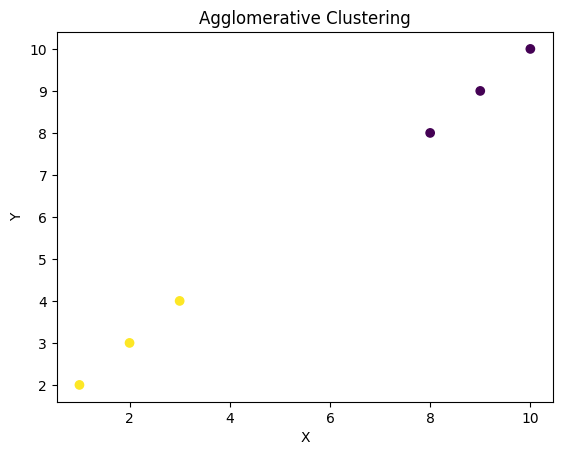

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 8],
    [9, 9],
    [10, 10]
])
model = AgglomerativeClustering(n_clusters=2)
labels = model.fit_predict(X)
print("Cluster labels:", labels)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Agglomerative Clustering")
plt.show()

Cluster 1
[[ 1  2]
 [ 8  8]
 [ 9  9]
 [10 10]]

Cluster 2
[[2 3]
 [3 4]]



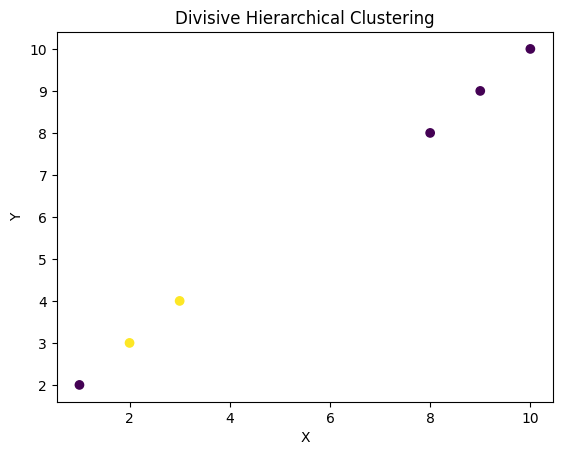

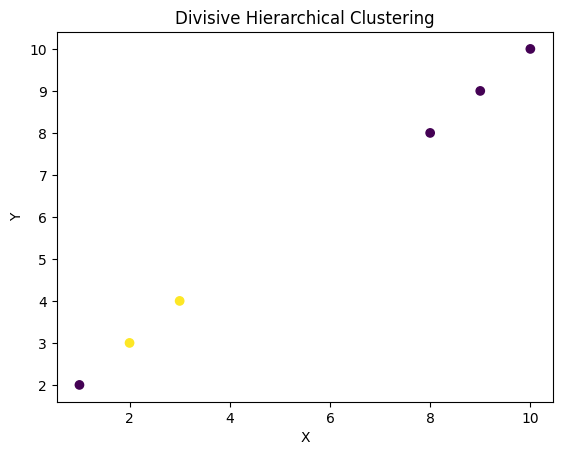

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 8],
    [9, 9],
    [10, 10]
])

def distance(a, b):
    return np.linalg.norm(a - b)
clusters = [list(range(len(X)))]

while len(clusters) < 2:


    cluster = max(clusters, key=len)
    clusters.remove(cluster)


    avg_distances = []

    for i in cluster:
        distances = [
            distance(X[i], X[j])
            for j in cluster
            if i != j
        ]
        avg_distances.append((i, np.mean(distances)))

    split_point = max(avg_distances, key=lambda x: x[1])[0]


    cluster1 = [split_point]
    cluster2 = [i for i in cluster if i != split_point]

    for i in cluster2[:]:
        d1 = distance(X[i], X[split_point])

        center = np.mean(X[cluster2], axis=0)
        d2 = distance(X[i], center)

        if d1 > d2:
            cluster2.remove(i)
            cluster1.append(i)

    clusters.append(cluster1)
    clusters.append(cluster2)

for i, cluster in enumerate(clusters):
    print("Cluster", i + 1)
    print(X[cluster])
    print()

labels = np.zeros(len(X), dtype=int)

for i, cluster in enumerate(clusters):
    for point in cluster:
        labels[point] = i


plt.scatter(X[:, 0], X[:, 1], c=labels)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Divisive Hierarchical Clustering")
plt.show()